In [2]:
import random 
import time 

import numpy
import matplotlib.pyplot

%matplotlib inline

In [3]:
class Desempenho:
    
    def __init__(self):
        self.instrucoes = 0
        self.tempo_inicial = 0
        self.tempo_final = 0

    def reiniciar(self):
        self.instrucoes = 0
        self.tempo_inicial = 0
        self.tempo_final = 0

    def inicio_cronometrado(self):
        import time
        self.tempo_inicial = time.perf_counter()

    def fim_cronometrado(self):
        import time
        self.tempo_final = time.perf_counter()

    @property
    def tempo_total(self):
        return self.tempo_final - self.tempo_inicial

In [4]:
class MergeSort:
    """Implementação do algoritmo Merge Sort focada em análise e métricas."""
    def __init__(self):
        self.metricas = Desempenho()

    def ordenacao(self, vetor):
        """Ponto de entrada público para o processo de ordenação."""
        self.metricas.reiniciar()
        self.metricas.inicio_cronometrado()
        
        vetor_resultado = self._divisao_recursiva(vetor)
        
        self.metricas.fim_cronometrado()
        return vetor_resultado

    def _divisao_recursiva(self, vetor):
        """Fase de Divisão: Quebra o vetor até atingir o caso base."""
        self.metricas.instrucoes += 1 
        if len(vetor) <= 1:
            return vetor

        meio_vetor = len(vetor) // 2
        self.metricas.instrucoes += 2  

        metade_esquerda = self._divisao_recursiva(vetor[:meio_vetor])
        metade_direita = self._divisao_recursiva(vetor[meio_vetor:])

        return self._uniao_ordenada(metade_esquerda, metade_direita)

    def _uniao_ordenada(self, esquerda, direita):
        vetor_unido = []
        ponteiro_esq = ponteiro_dir = 0

        while ponteiro_esq < len(esquerda) and ponteiro_dir < len(direita):
            self.metricas.instrucoes += 2  
            
            if esquerda[ponteiro_esq] <= direita[ponteiro_dir]:
                vetor_unido.append(esquerda[ponteiro_esq])
                ponteiro_esq += 1
            else:
                vetor_unido.append(direita[ponteiro_dir])
                ponteiro_dir += 1
            self.metricas.instrucoes += 2  

        self.metricas.instrucoes += 1
        vetor_unido.extend(esquerda[ponteiro_esq:])
        
        self.metricas.instrucoes += 1
        vetor_unido.extend(direita[ponteiro_dir:])

        return vetor_unido

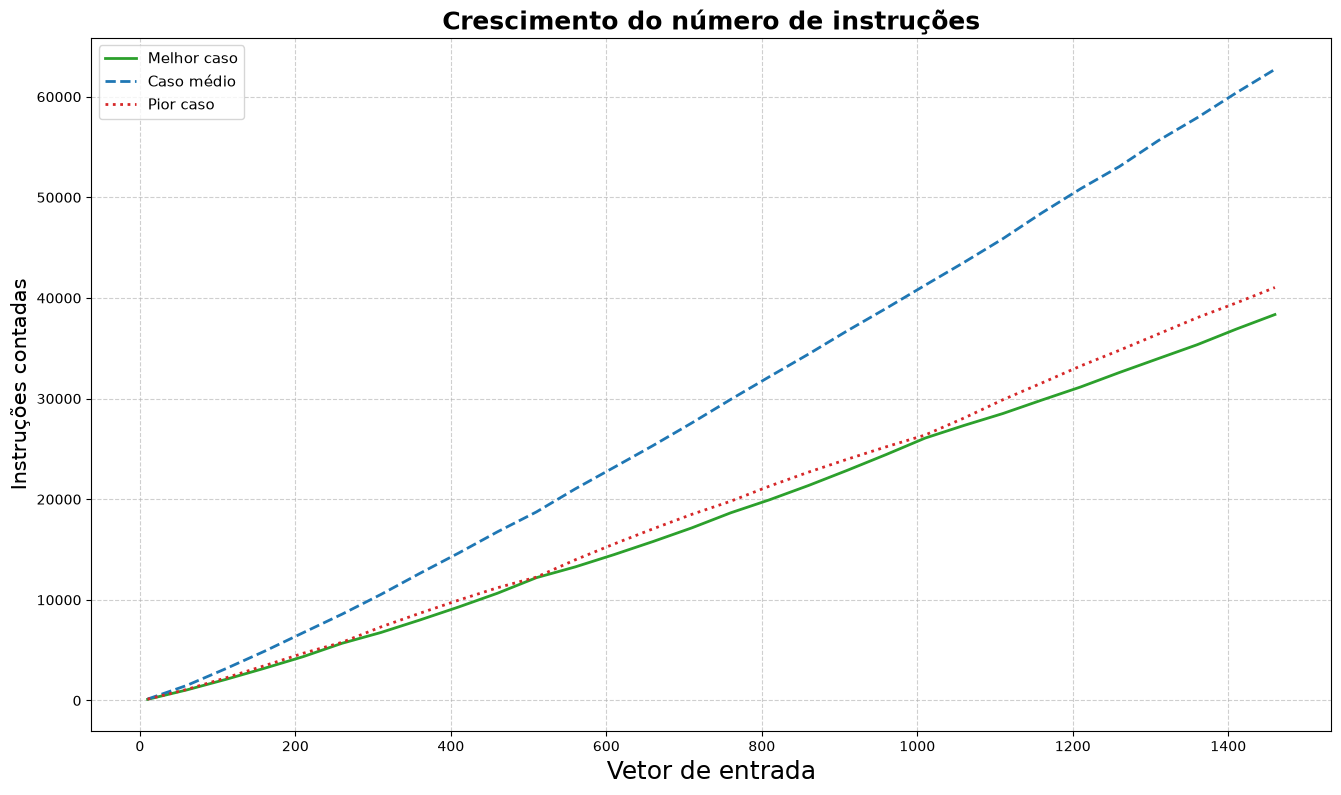

In [11]:
tamanhos_vetores = list(range(10, 1501, 50)) 

classificador = MergeSort()


metricas_melhor_caso = []     
metricas_caso_medio = []       
metricas_pior_caso = []       

for tamanho in tamanhos_vetores:
    # melhor caso
    vetor_ordenado = list(range(tamanho))
    classificador.ordenacao(vetor_ordenado)
    metricas_melhor_caso.append(classificador.metricas.instrucoes)

    # caso médio 
    vetor_aleatorio = [random.randint(0, 10000) for _ in range(tamanho)]
    classificador.ordenacao(vetor_aleatorio)
    metricas_caso_medio.append(classificador.metricas.instrucoes)

    # pior caso 
    vetor_decrescente = list(range(tamanho, 0, -1))
    classificador.ordenacao(vetor_decrescente)
    metricas_pior_caso.append(classificador.metricas.instrucoes)

plt.figure(figsize=(16, 9))

plt.plot(tamanhos_vetores, metricas_melhor_caso, label='Melhor caso', color='#2ca02c', linewidth=2)
plt.plot(tamanhos_vetores, metricas_caso_medio, label='Caso médio', color='#1f77b4', linestyle='--', linewidth=2)
plt.plot(tamanhos_vetores, metricas_pior_caso, label='Pior caso', color='#d62728', linestyle=':', linewidth=2)

plt.title('Crescimento do número de instruções', fontsize=18, fontweight='bold')
plt.xlabel('Vetor de entrada', fontsize=18)
plt.ylabel('Instruções contadas', fontsize=15)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)

# Exibição do gráfico dentro do Jupyter Notebook
plt.show()